In [1]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from scipy.special import gammaln
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
from pathlib import Path
import torch

plt.rcParams.update({
    'font.size': 20,
    'font.family': 'Nimbus Sans'
})


class yeast_geno_data:
    def __init__(self, geno_data_path, ids_path, snp_info_path, 
                 gene_info_path, gpu_device='cpu'):

        self.geno = np.load(geno_data_path)
        self.geno_t = torch.tensor(self.geno, device=gpu_device)

        self.ids = np.loadtxt(ids_path, delimiter='\t', dtype='int')
        self.snp_info = pd.read_csv(snp_info_path, delimiter='\t', index_col=0)
        self.gene_info = pd.read_csv(gene_info_path)

        self.L = self.geno.shape[1]
        
    def sub_sample_snps(self, r2_threshold):
        lim = self.L
        loci = [0]
        i = 0

        while i < lim:
            j = i + 1

            while (j < lim) and (
                torch.corrcoef(self.geno_t[:, [i, j]].t())[0, 1] ** 2 >= r2_threshold
            ):
                j += 1

            if j < lim:
                i = j
                loci.append(i)
            else:
                break

        self.loci_chosen = loci

        self.abs_pos = {
            locus: get_abs_pos(
                *list(self.snp_info.loc[locus][['Chromosome', 'Position (bp)']])
            )
            for locus in self.loci_chosen
        }

    def get_geno(self, snps):
        return self.geno[:, snps]


class yeast_fitness_data:
    def __init__(self, treatment, conditions, in_path):
        self.treatment = treatment
        self.conditions = conditions
        self.in_path = in_path
        
    def load_condition(self, condition, fitness):        
        dfs = [
            pd.read_csv(self.in_path / f'fitness/{condition}_{rep}.tsv').set_index('Number')
            for rep in [1, 2, 3]
        ]

        df_reps = pd.concat(dfs, axis=1, join='outer')
        df_reps['Idx'] = df_reps.index

        df_fit = df_reps[fitness].copy()
        df_fit['mean_log_fit'] = df_fit.mean(1)
        df_fit['std_log_fit'] = df_fit.std(1)
        
        return df_fit
    
    def load_all_conditions(self, fitness, sub=None):
        df_fits = {}

        for condition in self.conditions:
            df_fits[condition] = self.load_condition(condition, fitness)
            
        self.df_fits_all = pd.concat(list(df_fits.values()), axis=1, join='outer')
        self.df_fits = self.df_fits_all[['mean_log_fit', 'std_log_fit']]

        if sub is not None and len(sub) != 0:
            self.df_fits = self.df_fits[sub]
        
    def get_fit_data(self, ids, dropna=True):
        if dropna:
            data = self.df_fits.loc[ids].dropna()
        else:
            data = self.df_fits.loc[ids]
        
        return data


import statsmodels.formula.api as smf
import statsmodels.api as sm


class yeast_data:
    def __init__(self, geno_data, fitness_data):
        self.geno_data = geno_data
        self.fitness_data = fitness_data
        
        self.ids = set(self.geno_data.ids).intersection(list(self.fitness_data.df_fits.index))
        self.ids = list(self.ids)
        self.ids.sort()

        self.ids_geno_pos = np.where(np.isin(self.geno_data.ids, self.ids))[0]
        
        self.geno = self.geno_data.geno[self.ids_geno_pos]
        self.fitness = self.fitness_data.df_fits.loc[self.ids]
        
        self.cat_to_con = dict(enumerate(self.fitness_data.conditions))
        self.con_to_cat = {v: k for k, v in self.cat_to_con.items()}

        self.con_to_num = {'C': 0, 'Q': .25, 'H': .5, 'F': 1, 'D': 2}
        self.num_to_con = {v: k for k, v in self.con_to_num.items()}
        
    def calc_snp_effect(self, locus):
        mean_fit_BY = self.fitness[self.geno[:, locus] == 0]['mean_log_fit'].mean(0) 
        mean_fit_RM = self.fitness[self.geno[:, locus] == 1]['mean_log_fit'].mean(0)

        diff = mean_fit_BY - mean_fit_RM
        diff.index = self.fitness_data.conditions

        return diff
    
    def get_main_effects(self, loci):
        main_effects = {}

        for locus in loci:
            main_effects[locus] = self.calc_snp_effect(locus)

        return pd.DataFrame(main_effects).T
    
    def stack_data(self, conditions_test):
        self.conditions_test = conditions_test
        conditions_test = pd.Series(conditions_test)

        col_idx = conditions_test.map(self.con_to_cat).tolist()

        self.fitness_stacked = np.array(
            self.fitness['mean_log_fit'].iloc[:, col_idx]
        ).reshape(-1)

        self.std_stacked = np.array(
            self.fitness['std_log_fit'].iloc[:, col_idx]
        ).reshape(-1)

        conditions_test_ = conditions_test.map(self.con_to_num).tolist()
        self.cons = np.array([conditions_test_ for _ in range(len(self.geno))]).flatten()

    def calc_GxE_pvalue(self, locus):
        X = self.geno[:, locus]
        X_ = np.repeat(X, len(self.conditions_test)).flatten()

        df_data = pd.DataFrame({
            "fitness": self.fitness_stacked,
            "condition": self.cons,
            "genotype": X_,
            "sigma": self.std_stacked
        })

        df_data = df_data.dropna()
        df_data = df_data[df_data.sigma < df_data.sigma.quantile(.25)]

        model_wls = smf.wls(
            "fitness ~ genotype + condition + genotype * condition",
            data=df_data
        ).fit()

        anova_results = sm.stats.anova_lm(model_wls, typ=2)

        pvalue = anova_results.loc['genotype:condition']['PR(>F)']
        coef = model_wls.params['genotype:condition']
        
        return pvalue, coef
    
    
yeast_chr_lengths = [
    230218, 813184, 316620, 1531933, 576874, 270161, 1090940, 562643,
    439888, 745751, 666816, 1078177, 924431, 784333, 1091291, 948066
]

yeast_chr_size = np.array(yeast_chr_lengths).sum()

chr_labels_arabic = [str(i) for i in range(1, 17)]
chr_offsets = np.cumsum([0] + yeast_chr_lengths[:-1])


def get_abs_pos(chrom, chrom_pos):
    return (chrom_pos - 1) + dict(enumerate(chr_offsets))[chrom - 1]


from matplotlib.patches import Rectangle
import matplotlib.transforms as transforms


def make_man(abs_pos, y, ylab, df_lab=None, chrom=None, chrom_range=None, constrained_layout=False):

    plt.rcParams.update({
        'font.size': 24,
        'font.family': 'Nimbus Sans'
    })

    fig, ax = plt.subplots(figsize=(14, 4), constrained_layout=constrained_layout)
    
    ax.bar(
        abs_pos,
        y,
        width=20000,
        color='black'
    )

    ax.margins(x=0.05, y=0.2)
    
    if df_lab is not None:
        for _, row in df_lab.iterrows():
            name = row.iloc[2]
            x, y = row.iloc[:2]

            if y > 0:
                y_offset = 5
            else: 
                y_offset = -7

            ax.annotate(
                name,
                xy=(x, y),
                xytext=(0, y_offset),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=10,
                color='red'
            )

    for offset in chr_offsets[1:]:
        ax.axvline(offset, color='lightgray', lw=2, zorder=0)

    midpoints = [offset + length / 2 for offset, length in zip(chr_offsets, yeast_chr_lengths)]
    ax.set_xticks(midpoints)
    ax.set_xticklabels(chr_labels_arabic, fontsize=12, fontweight='bold')
    
    if chrom is None:
        ax.set_xlim(0, yeast_chr_size)
    else:
        if chrom_range is None:        
            ax.set_xlim(chr_offsets[chrom], chr_offsets[chrom + 1])
        else:
            ax.set_xlim(
                chr_offsets[chrom] + chrom_range[0],
                chr_offsets[chrom] + chrom_range[1]
            )

    ax.set_xlabel('Chromosome', fontsize=18)
    ax.set_ylabel(f'{ylab}', fontsize=18)
    ax.margins(x=0)

    return fig, ax


def add_labels(ax, name, x, y, color):

    df_lab = pd.DataFrame({'name': name, 'x': x, 'y': y})

    for _, row in df_lab.iterrows():
        name = row.iloc[0]
        x, y = row.iloc[1:]

        if y > 0:
            y_offset = 5
        else: 
            y_offset = -7

        ax.annotate(
            name,
            xy=(x, y),
            xytext=(0, y_offset),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=14,
            color=color
        )

    return ax

In [2]:
# load genotype data

path = Path("/orange/juannanzhou/MarginalEpistasis/data/")
geno_data_path = path / "geno_top_25.npy"
ids_path = path / "index_top_25.tsv"
snp_info_path = "/blue/juannanzhou/arindam.sarkar/BB-QTL_HT/6_KEGG_enrichment/data/snp_info_complete.tsv"
gene_info_path = "/blue/juannanzhou/arindam.sarkar/BB-QTL_HT/6_KEGG_enrichment/data/gene_info.csv"

geno_data = yeast_geno_data(
    geno_data_path,
    ids_path,
    snp_info_path,
    gene_info_path,
    gpu_device='cpu'
)

geno_data.sub_sample_snps(r2_threshold=.99)

r2_mat = torch.corrcoef(
    geno_data.geno_t[:, geno_data.loci_chosen[:]].t()
) ** 2

r2_mat = r2_mat.numpy()

# load fitness data

conditions = ['C', 'H', 'F', 'D']
treatment = 'Pulvinatal'

in_path = Path(f'/orange/juannanzhou/juannanzhou/BBQTL-HT/{treatment}/results')

p0_counts = pd.read_csv(in_path / "fitness/F_1.tsv")['P0']
p0_freqs = p0_counts / p0_counts.sum(0)

sub = p0_freqs > 10**-6

print(f'number of genotypes chosen = {sub.sum()}')

fitness_data = yeast_fitness_data(treatment, conditions, in_path)
fitness_data.load_all_conditions('log_fitness1', sub=sub)

# combine genotype and phenotype data

data = yeast_data(geno_data, fitness_data)

main_effects = data.get_main_effects(geno_data.loci_chosen)

number of genotypes chosen = 74688


In [3]:
# data.stack_data(['C', 'H'])
# data.stack_data(['Q', 'H', 'F'])
data.stack_data(['C', 'H', 'F', 'D'])

results = {locus: data.calc_GxE_pvalue(locus) for locus in data.geno_data.loci_chosen}

In [4]:
df_gxe = pd.DataFrame(results).T
df_gxe.columns = ['pvalue_raw', 'coef']
df_gxe['abs_pos'] = list(data.geno_data.abs_pos.values())

print(f'number of snps with zero p-value = {(df_gxe.pvalue_raw == 0).sum()}')

pseudo_v = 1e-300
df_gxe['pvalue'] = -np.log10(df_gxe['pvalue_raw'] + pseudo_v)

number of snps with zero p-value = 13


In [16]:
# pseudo_v = 1e-300
# # pseudo_v = 0
# df_gxe.pvalue = -1 * np.log10(df_gxe.pvalue + pseudo_v) # convert to negative log10

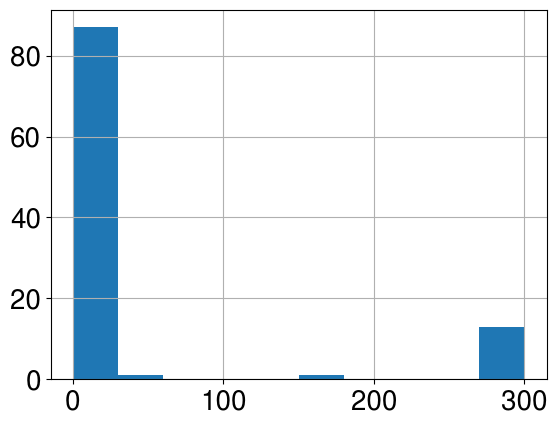

In [6]:
value = 'pvalue'

l = len(df_plot)

b = 20
local_max = []
for i in range(l):
    start, end = max(0, i - b), min(i + b + 1, l)    
    local_max.append(np.abs(df_plot[value].iloc[i]) == df_plot[value].iloc[start:end].abs().max())

df_plot_max = df_plot[local_max]
# df_plot_max = df_plot_max.drop_duplicates(subset=['gene'])
# df_plot_max = df_plot_max.drop_duplicates(subset=['effect'])
df_plot_max = df_plot[local_max]

df_plot_max[value].abs().hist()
plt.show()

# df_plot_max[df_plot_max.effect > 20].gene.drop_duplicates().to_csv("top_genes.txt", index=None, header=None)

In [7]:
df_plot = df_gxe.copy()

genes = list(geno_data.snp_info.loc[df_plot.index].gene_standard_name)
df_plot['gene'] = genes

# Add gene column to df_plot_max as well
df_plot_max = df_plot_max.copy()
df_plot_max["gene"] = df_plot.loc[df_plot_max.index, "gene"].values

top_genes = (
    df_plot_max
    .sort_values("pvalue", ascending=False)
    ["gene"]
    .dropna()
    .drop_duplicates()
    .head(100)
    .tolist()
)

len(top_genes)
top_genes[:20]

['RPL25',
 'YGK3',
 'MDH2',
 'MED7',
 'PFK27',
 'BSC6',
 'ALR1',
 'YOL131W',
 'GAS4',
 'MKT1',
 'GLE2',
 'PHO84',
 'RMI1',
 'PCH2',
 'OAF1',
 'LYS14',
 'YHR007C-A',
 'VPS3',
 'PMR1',
 'SMC1']

In [8]:
len(set(top_genes))
top_genes[:30]

['RPL25',
 'YGK3',
 'MDH2',
 'MED7',
 'PFK27',
 'BSC6',
 'ALR1',
 'YOL131W',
 'GAS4',
 'MKT1',
 'GLE2',
 'PHO84',
 'RMI1',
 'PCH2',
 'OAF1',
 'LYS14',
 'YHR007C-A',
 'VPS3',
 'PMR1',
 'SMC1',
 'DRS1',
 'YDR514C',
 'YSR3',
 'ESL2',
 'GAT1',
 'YLR257W',
 'RRP1',
 'NOB1',
 'YJR128W',
 'GEP7']

In [9]:
# gene_highlights = pd.read_csv("fluconazole_genes.txt", header=None).iloc[:, 0].tolist()
gene_highlights = pd.DataFrame(columns=["gene"])

poss = []
for gene in gene_highlights:
    try:
        pos = np.where(np.array(df_plot.gene) == gene)[0][0]
        poss.append(pos)
    except: pass

df_plot_known_genes = df_plot.iloc[poss]

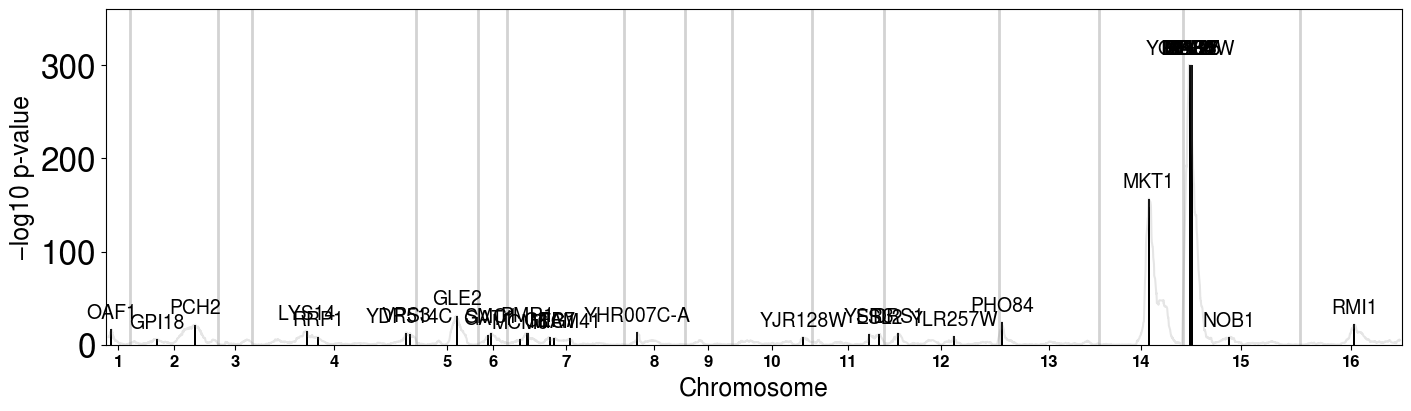

In [10]:
genes_to_exclude = []

threshold = 6

df_plot_max = df_plot_max[df_plot_max[value].abs() > threshold]
df_plot_known_genes = df_plot_known_genes[
    df_plot_known_genes[value] > threshold
]

df_plot_bars = pd.concat([df_plot_max, df_plot_known_genes])

fig, ax = make_man(
    df_plot_bars.abs_pos,
    df_plot_bars[value],
    ylab='−log10 p-value',
    constrained_layout=True
)

# No known Pulvinatal genes to exclude
genes_to_exclude = []

df_plot_max = df_plot_max[
    [gene not in set(genes_to_exclude)
     for gene in df_plot_max.gene]
]

# Keep this object — downstream enrichment may use it
df_plot_bg = df_plot_max.copy()

df_plot_bg = df_plot_bg[
    df_plot_bg[value].abs() > 1.0 * threshold
]

ax = add_labels(
    ax,
    df_plot_bg['gene'],
    df_plot_bg['abs_pos'],
    df_plot_bg[value],
    'black'
)

# Empty known genes (Pulvinatal)
ax = add_labels(
    ax,
    df_plot_known_genes['gene'],
    df_plot_known_genes['abs_pos'],
    df_plot_known_genes[value],
    'red'
)

# Plot genome-wide signal
ax.plot(
    df_plot['abs_pos'],
    df_plot[value],
    color='gray',
    lw=1.5,
    zorder=2,
    alpha=.2
)

plt.savefig('figures/man_plot.pdf', bbox_inches="tight")
plt.show()

### Enrichment new

In [11]:
import sys
print(sys.executable)

/apps/pytorch/2.8.0/bin/python


In [12]:
from scipy import stats
import gseapy as gp
from scipy.interpolate import make_interp_spline

def filter_gene_set(gene_set):
    return gene_set[[g in list(gene_info.index) for g in gene_set]]    

def get_gene_scores(gene_set):
    values = gene_info.loc[gene_set].pvalue_imputed
    return pd.Series(dict(zip(gene_set, values)))
    # return pd.Series(dict(zip(gene_set, values))), np.sum(values > 20) / len(values)    

# def get_stat(gene_set):
#     return get_gene_scores(gene_set).mean()

def get_stat(gene_set, threshold=20):
    res = get_gene_scores(gene_set)
    return (np.array(res) > 20).sum()/len(res)

In [13]:
gmt = gp.get_library(name='KEGG_2018', organism='Yeast')

In [14]:
# Create spline model
x = df_plot.abs_pos
y = df_plot.pvalue
x = np.pad(x, pad_width=1, mode='constant', constant_values=0)
x[-1] = yeast_chr_size
y = np.pad(y, pad_width=1, mode='constant', constant_values=0)
spl = make_interp_spline(x, y, k=3)  # k=3 for cubic spline

# df = df_plot
# df = df.drop_duplicates(subset=['gene'])
# df = df.set_index('gene')

In [17]:
gene_info = pd.read_csv("data/SGD_features.tab", sep='\t', header=None)
gene_info = gene_info[gene_info.iloc[:, 1] == 'ORF']
gene_info = gene_info.iloc[:, [3, 4, 8, 9, 10]]
gene_info.columns = ['gene_name', 'standard_name', 'chrom', 'chrom_start', 'chrom_end']
gene_info = gene_info[gene_info.chrom < 17]
mask = gene_info.standard_name.isna()
gene_info.loc[mask, 'standard_name'] = gene_info.loc[mask, 'gene_name']

gene_info['start_abs'] = gene_info.apply(lambda row: get_abs_pos(row['chrom'], row['chrom_start']), axis=1)
gene_info['end_abs'] = gene_info.apply(lambda row: get_abs_pos(row['chrom'], row['chrom_end']), axis=1)
gene_info['mid_abs'] = gene_info[['start_abs', 'end_abs']].mean(1)
gene_info = gene_info.sort_values(by='start_abs')
gene_info = gene_info.set_index('standard_name')
gene_info['pvalue_imputed'] = spl(gene_info['mid_abs']) #assign to each gene imputed -log p value

for g in gmt.keys():
    gene_set = np.array(gmt[g])
    gmt[g] = filter_gene_set(gene_set)

In [18]:
def get_gene_scores(gene_set):
    values = gene_info.loc[gene_set].pvalue_imputed
    return pd.Series(dict(zip(gene_set, values)))
    # return pd.Series(dict(zip(gene_set, values))), np.sum(values > 20) / len(values)    

# def get_stat(gene_set):
#     return get_gene_scores(gene_set).mean()

def get_stat(gene_set, threshold=10):
    res = get_gene_scores(gene_set)
    return (np.array(res) > threshold).sum()/len(res)

statistics = {}

for GO in gmt.keys(): 
    gene_set = gmt[GO]
    stat = get_stat(gene_set)
    statistics[GO] = stat

/scratch/local/33157974/ipykernel_2972199/3171646682.py:11: RuntimeWarning: invalid value encountered in scalar divide
  return (np.array(res) > threshold).sum()/len(res)


In [19]:
pd.Series(statistics).sort_values(ascending=False)[:20]

Propanoate metabolism  sce00640                                  0.461538
Glyoxylate and dicarboxylate metabolism  sce00630                0.366667
Citrate cycle (TCA cycle)  sce00020                              0.322581
Pyruvate metabolism  sce00620                                    0.279070
Neomycin, kanamycin and gentamicin biosynthesis sce00524         0.250000
Valine, leucine and isoleucine degradation  sce00280             0.230769
Butanoate metabolism  sce00650                                   0.222222
Riboflavin metabolism  sce00740                                  0.214286
Arachidonic acid metabolism  sce00590                            0.200000
Aminoacyl-tRNA biosynthesis  sce00970                            0.184211
Phenylalanine, tyrosine and tryptophan biosynthesis  sce00400    0.176471
GTP-binding proteins  sce04031                                   0.171429
Glycine, serine and threonine metabolism  sce00260               0.166667
Lectins  sce04091                     

#### Get bootstrap p values

In [20]:
genes = list(gene_info.index)

empircal p value = 0.07409999999999994 corrected p value = 9.855299999999993


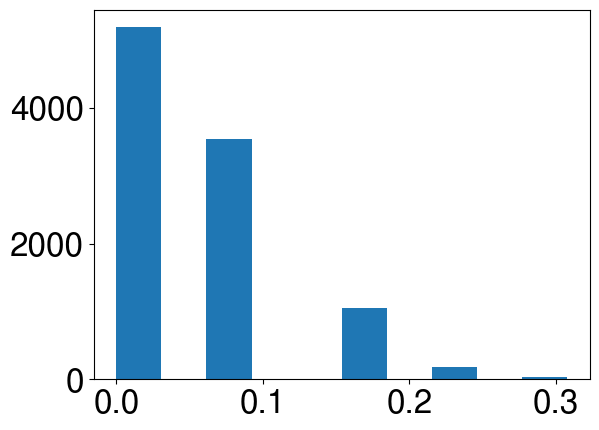

In [21]:
GO = 'Propanoate metabolism  sce00640'

gene_set = gmt[GO]
n_genes = len(gene_set)

test_stat = get_stat(gene_set, threshold=20)

samples = []
for _ in range(10000):
    
    gene_samples = np.random.choice(genes, n_genes)
    sample_stat = get_stat(gene_samples, threshold=20)
    samples.append(sample_stat)

p_emp = (1 - stats.percentileofscore(samples, test_stat)/100)
plt.hist(samples)
print(f'empircal p value = {p_emp}', f'corrected p value = {p_emp * 133}')

In [22]:
def get_GO_p_value(GO, threshold, n_samples=1000):
    gene_set = gmt[GO]
    n_genes = len(gene_set)

    test_stat = get_stat(gene_set, threshold=threshold)

    samples = []
    for _ in range(n_samples):

        gene_samples = np.random.choice(genes, n_genes)
        sample_stat = get_stat(gene_samples, threshold=threshold)
        samples.append(sample_stat)

    p_emp = (1 - stats.percentileofscore(samples, test_stat)/100)
    
    return p_emp

In [23]:
GO_terms = gmt.keys()

In [26]:
!/apps/pytorch/2.8.0/bin/python -m pip install --user tqdm

  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
Using cached tqdm-4.67.3-py3-none-any.whl (78 kB)


In [27]:
from tqdm import tqdm

threshold = 10

GO_pvalue = {}

for GO in tqdm(GO_terms):
    try:
        GO_pvalue[GO] = get_GO_p_value(GO, threshold=threshold)
    except:
        pass

 97%|█████████▋| 129/133 [03:31<00:06,  1.65s/it]/scratch/local/33157974/ipykernel_2972199/3171646682.py:11: RuntimeWarning: invalid value encountered in scalar divide
  return (np.array(res) > threshold).sum()/len(res)
/scratch/local/33157974/ipykernel_2972199/3171646682.py:11: RuntimeWarning: invalid value encountered in scalar divide
  return (np.array(res) > threshold).sum()/len(res)
/scratch/local/33157974/ipykernel_2972199/3171646682.py:11: RuntimeWarning: invalid value encountered in scalar divide
  return (np.array(res) > threshold).sum()/len(res)
/scratch/local/33157974/ipykernel_2972199/3171646682.py:11: RuntimeWarning: invalid value encountered in scalar divide
  return (np.array(res) > threshold).sum()/len(res)
/scratch/local/33157974/ipykernel_2972199/3171646682.py:11: RuntimeWarning: invalid value encountered in scalar divide
  return (np.array(res) > threshold).sum()/len(res)
/scratch/local/33157974/ipykernel_2972199/3171646682.py:11: RuntimeWarning: invalid value encoun

In [28]:
GO_pvalue = pd.Series(GO_pvalue).sort_values()
GO_pvalue.to_csv(f"{treatment}_GO_enrichment_p_value.tsv")